In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

In [23]:
df_total_sales = train.groupby('date')['sales'].sum()

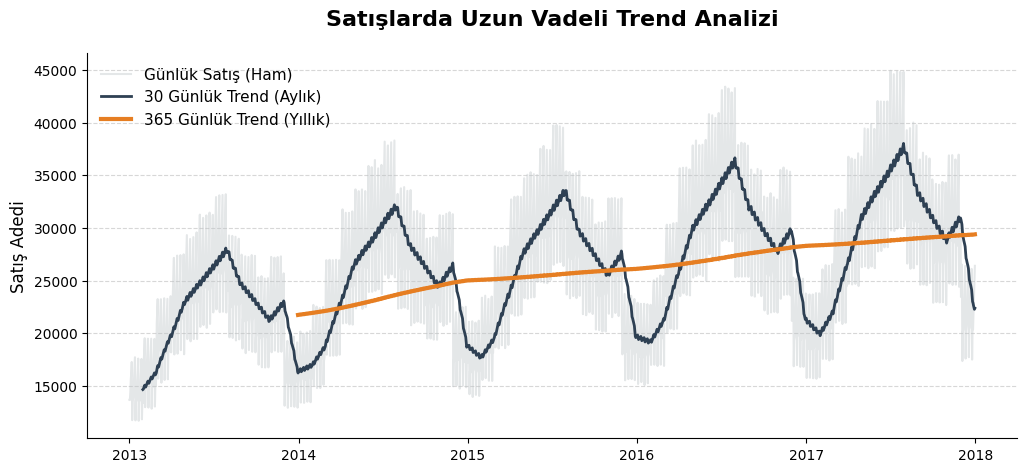

In [31]:
# STANDART: Trend Analizi (Ham Veri + Hareketli Ortalamalar)
plt.figure(figsize=(12, 5))

# 1. Hesaplama & Çizim
plt.plot(df_total_sales.index, df_total_sales.values, color='#BDC3C7', alpha=0.4, label='Günlük Satış (Ham)')
plt.plot(df_total_sales.rolling(window=30).mean(), color='#2E4053', linewidth=2, label='30 Günlük Trend (Aylık)')
plt.plot(df_total_sales.rolling(window=365).mean(), color='#E67E22', linewidth=3, label='365 Günlük Trend (Yıllık)')

# 2. Estetik Ayarlar
plt.title('Satışlarda Uzun Vadeli Trend Analizi', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Satış Adedi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(frameon=False, fontsize=11)
sns.despine()

plt.show()

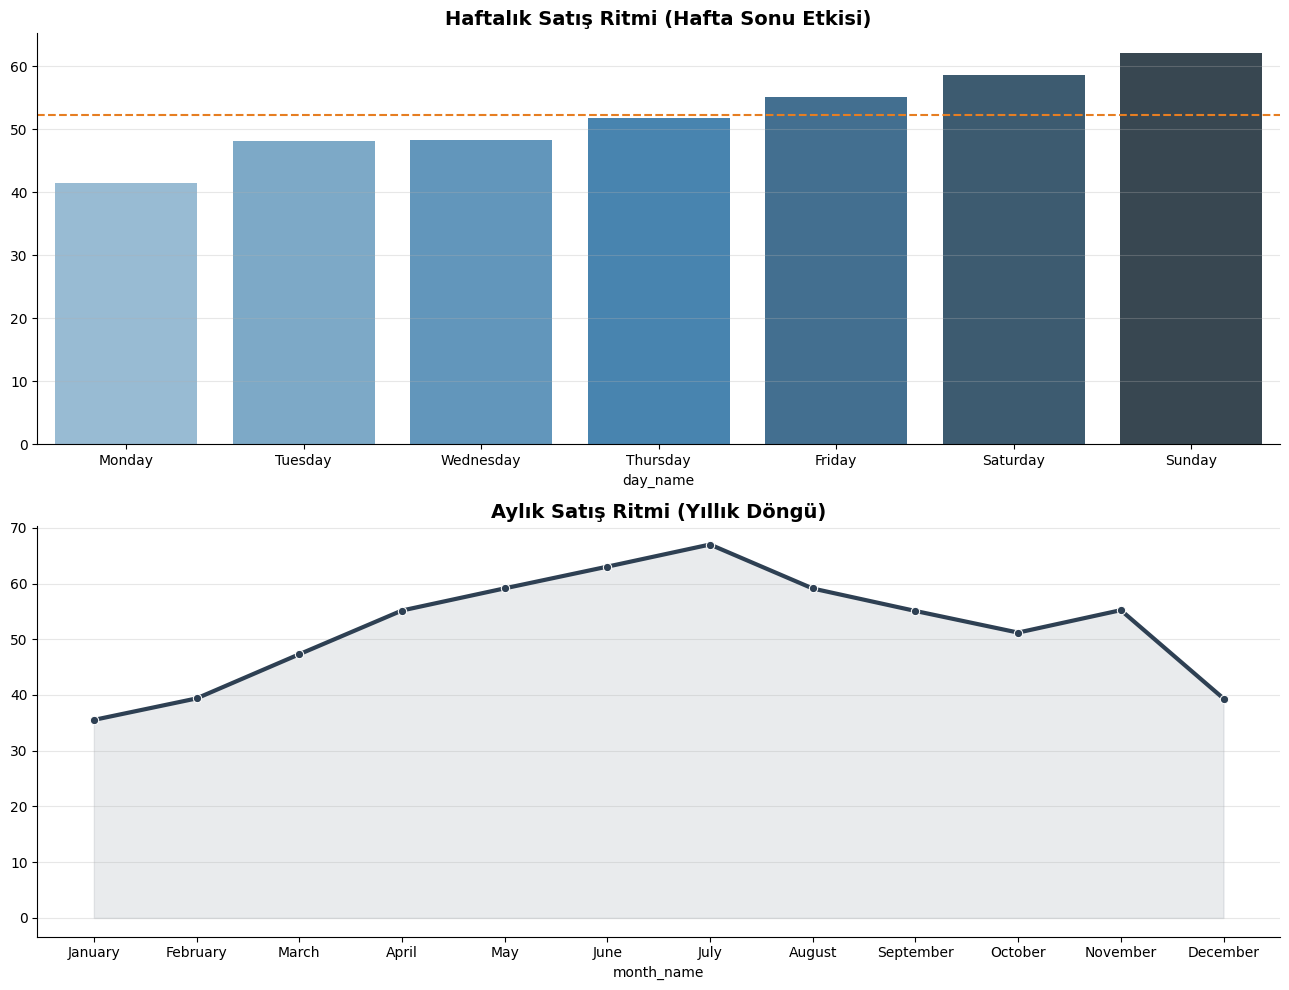

In [32]:
# STANDART: Mevsimsel Döngülerin Hesaplanması
temp_df = train.copy()
temp_df['day_name'] = temp_df['date'].dt.day_name()
temp_df['month_name'] = temp_df['date'].dt.month_name()

# Haftalık ve Aylık Ortalamalar
weekly_pattern = temp_df.groupby('day_name')['sales'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
monthly_pattern = temp_df.groupby('month_name')['sales'].mean().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

fig, ax = plt.subplots(2, 1, figsize=(13, 10))

# Haftalık Çizim
sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, ax=ax[0], palette='Blues_d')
ax[0].set_title('Haftalık Satış Ritmi (Hafta Sonu Etkisi)', fontsize=14, fontweight='bold')
ax[0].axhline(weekly_pattern.mean(), color='#E67E22', linestyle='--', label='Genel Ortalama')

# Aylık Çizim
sns.lineplot(x=monthly_pattern.index, y=monthly_pattern.values, ax=ax[1], marker='o', color='#2E4053', linewidth=3)
ax[1].fill_between(monthly_pattern.index, monthly_pattern.values, alpha=0.1, color='#2E4053')
ax[1].set_title('Aylık Satış Ritmi (Yıllık Döngü)', fontsize=14, fontweight='bold')

for a in ax:
    sns.despine(ax=a)
    a.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

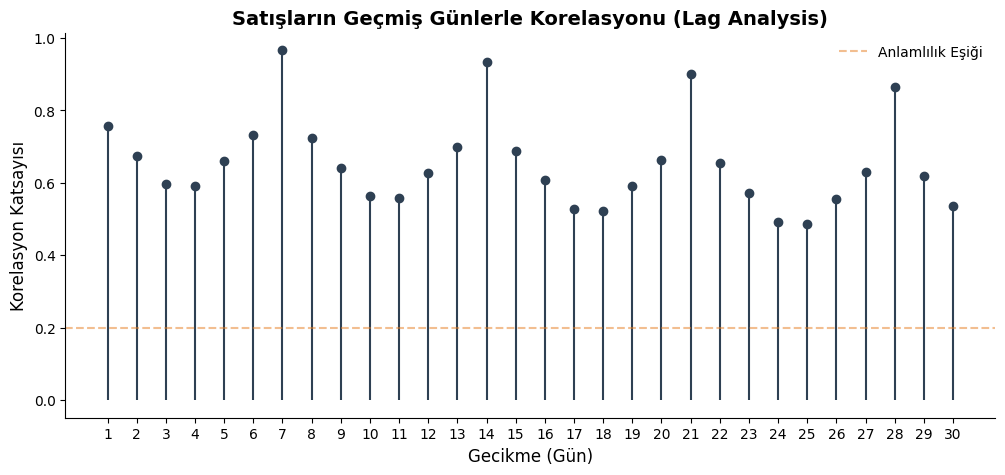

In [33]:
# STANDART: Manuel Otokorelasyon (Lag Correlation)
lags = range(1, 31) # İlk 30 gün
correlations = [df_total_sales.corr(df_total_sales.shift(i)) for i in lags]

plt.figure(figsize=(12, 5))
plt.stem(lags, correlations, linefmt='#2E4053', markerfmt='o', basefmt=' ')
plt.axhline(0.2, color='#E67E22', linestyle='--', alpha=0.5, label='Anlamlılık Eşiği')

plt.title('Satışların Geçmiş Günlerle Korelasyonu (Lag Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Gecikme (Gün)', fontsize=12)
plt.ylabel('Korelasyon Katsayısı', fontsize=12)
plt.xticks(lags)
plt.legend(frameon=False)
sns.despine()
plt.show()

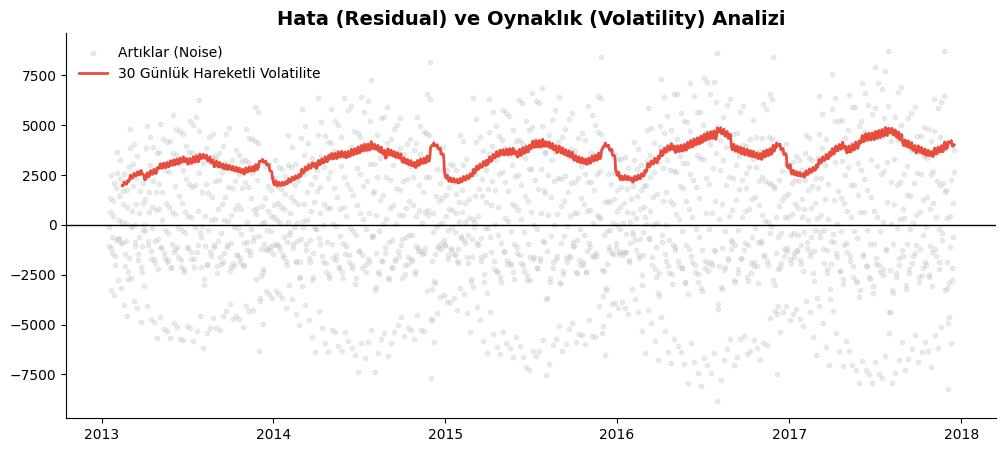

In [35]:
# STANDART: Manuel Residual (Artık) ve Volatilite Hesabı
trend_30 = df_total_sales.rolling(window=30, center=True).mean()
residuals = df_total_sales - trend_30
volatility = residuals.rolling(window=30).std()

plt.figure(figsize=(12, 5))

# Artıkların Dağılımı
plt.scatter(df_total_sales.index, residuals, alpha=0.3, color='#BDC3C7', s=10, label='Artıklar (Noise)')
# Volatilite Bandı
plt.plot(volatility, color='#E74C3C', linewidth=2, label='30 Günlük Hareketli Volatilite')

plt.title('Hata (Residual) ve Oynaklık (Volatility) Analizi', fontsize=14, fontweight='bold')
plt.axhline(0, color='black', linewidth=1)
plt.legend(loc='upper left', frameon=False)
sns.despine()
plt.show()

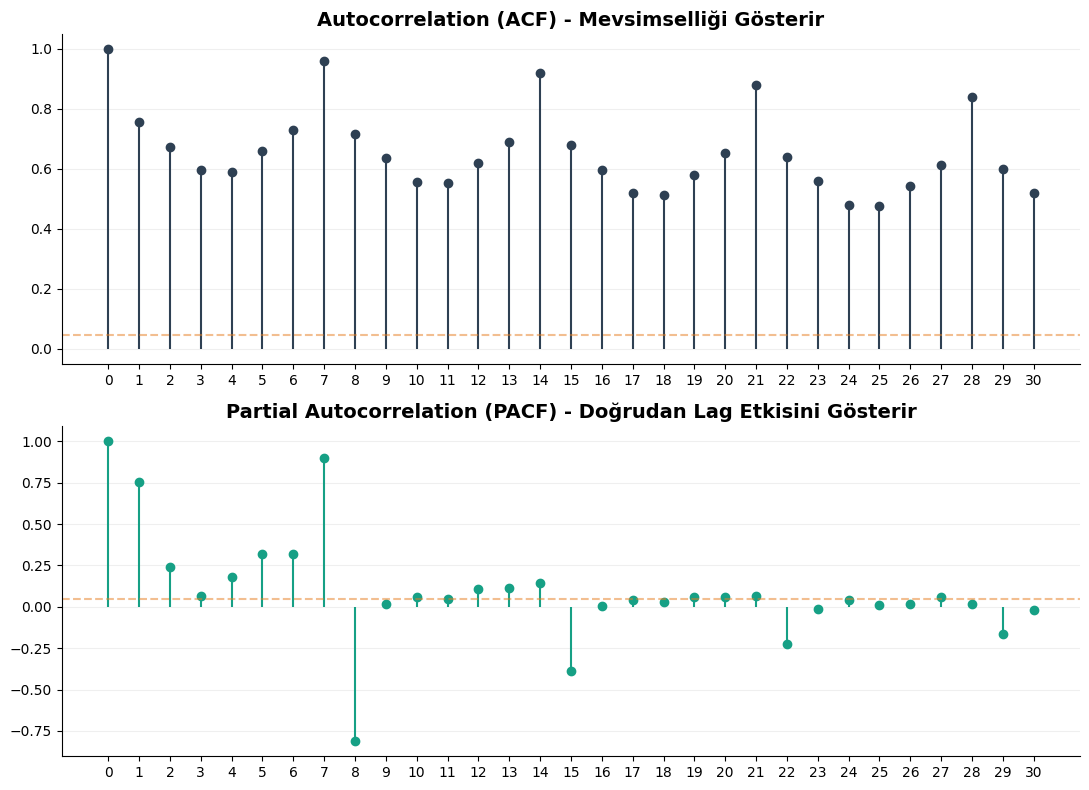

In [38]:
from statsmodels.tsa.stattools import acf, pacf

# 1. Hesaplama
lags = 30
acf_values = acf(df_total_sales, nlags=lags)
pacf_values = pacf(df_total_sales, nlags=lags, method='ols')

# 2. Görselleştirme
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11,8))

# ACF Plot
ax1.stem(range(lags + 1), acf_values, linefmt='#2E4053', markerfmt='o', basefmt=' ')
ax1.axhline(1.96/np.sqrt(len(df_total_sales)), linestyle='--', color='#E67E22', alpha=0.5) # %95 Güven Aralığı
ax1.set_title('Autocorrelation (ACF) - Mevsimselliği Gösterir', fontsize=14, fontweight='bold')

# PACF Plot
ax2.stem(range(lags + 1), pacf_values, linefmt='#16A085', markerfmt='o', basefmt=' ')
ax2.axhline(1.96/np.sqrt(len(df_total_sales)), linestyle='--', color='#E67E22', alpha=0.5)
ax2.set_title('Partial Autocorrelation (PACF) - Doğrudan Lag Etkisini Gösterir', fontsize=14, fontweight='bold')

for a in [ax1, ax2]:
    sns.despine(ax=a)
    a.set_xticks(range(lags + 1))
    a.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

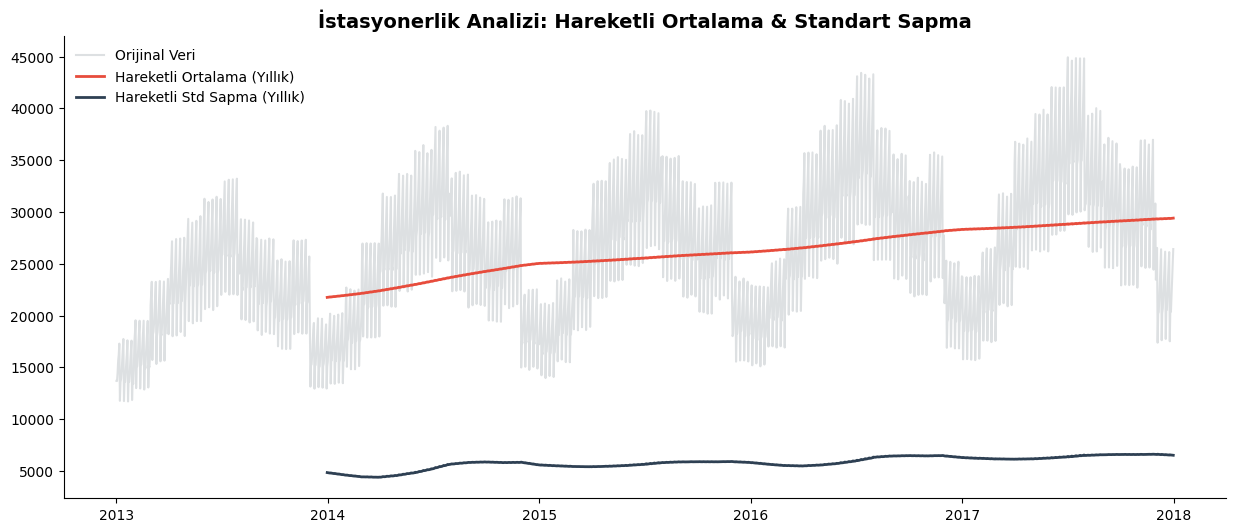

ADF Test İstatistiği: -3.0602
p-değeri: 0.0296


In [29]:
# STANDART: Rolling Statistics (Durağanlık Görseli)
window = 365 # Yıllık pencere trendi temiz görmek için idealdir
rolmean = df_total_sales.rolling(window=window).mean()
rolstd = df_total_sales.rolling(window=window).std()

plt.figure(figsize=(15, 6))
plt.plot(df_total_sales, color='#BDC3C7', alpha=0.5, label='Orijinal Veri')
plt.plot(rolmean, color='#E74C3C', linewidth=2, label='Hareketli Ortalama (Yıllık)')
plt.plot(rolstd, color='#2E4053', linewidth=2, label='Hareketli Std Sapma (Yıllık)')

plt.title('İstasyonerlik Analizi: Hareketli Ortalama & Standart Sapma', fontsize=14, fontweight='bold')
plt.legend(frameon=False)
sns.despine()
plt.show()

# ADF Test Sonucu (Markdown olarak notebook'a eklenebilir)
dftest = adfuller(df_total_sales, autolag='AIC')
print(f"ADF Test İstatistiği: {dftest[0]:.4f}")
print(f"p-değeri: {dftest[1]:.4f}") # 0.05'ten küçükse durağan kabul edilir.